In [7]:
import sionna.rt
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import drjit as dr

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, \
    PathSolver, RadioMapSolver, AntennaPattern, register_antenna_pattern

In [8]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True) # Merge shapes to speed-up computations
scene.frequency = 3.5e9

In [9]:
# scene.preview();

In [10]:
# Define custom antenna pattern function with constrained azimuth and elevation
def constrained_antenna_function(theta: mi.Float, phi: mi.Float, 
                                azimuth_range=(-180, 180), 
                                elevation_range=(-90, 90)) -> tuple:
    """
    Antenna pattern constrained to azimuth and elevation ranges
    
    Parameters:
    - azimuth_range: tuple (min, max) in degrees, range -180 to 180
    - elevation_range: tuple (min, max) in degrees, range -90 to 90
    
    theta: zenith angle in radians (0=vertical, pi/2=horizon)
    phi: azimuth angle in radians (-pi to pi)
    """
    # Convert azimuth constraints to radians
    phi_min = np.deg2rad(azimuth_range[0])
    phi_max = np.deg2rad(azimuth_range[1])
    
    # Convert elevation to zenith angles
    # elevation = 90 - zenith, so: zenith = 90 - elevation
    theta_min = np.deg2rad(90 - elevation_range[1])  # higher elevation → lower zenith
    theta_max = np.deg2rad(90 - elevation_range[0])  # lower elevation → higher zenith
    
    # Gaussian envelope for smooth constraints
    phi_center = (phi_min + phi_max) / 2
    phi_width = (phi_max - phi_min) / 4
    phi_envelope = dr.exp(-0.5 * ((phi - phi_center) / phi_width)**2)
    
    theta_center = (theta_min + theta_max) / 2
    theta_width = (theta_max - theta_min) / 4
    theta_envelope = dr.exp(-0.5 * ((theta - theta_center) / theta_width)**2)
    
    # Combined constraint gain
    constraint_gain = phi_envelope * theta_envelope
    
    # Base antenna pattern (vertically polarized sine)
    base_pattern = dr.abs(dr.sin(theta))
    
    # Apply constraints
    c_theta = mi.Complex2f(base_pattern * constraint_gain, 0)
    c_phi = mi.Complex2f(0, 0)  # No cross-pol component
    
    return c_theta, c_phi


# Create AntennaPattern subclass
class ConstrainedAntennaPattern(AntennaPattern):
    """Custom antenna pattern with azimuth/elevation constraints"""
    
    def __init__(self, azimuth_range=(-180, 180), elevation_range=(-90, 90)):
        self.azimuth_range = azimuth_range
        self.elevation_range = elevation_range
        self.patterns = [
            lambda theta, phi: constrained_antenna_function(theta, phi, 
                                                           azimuth_range=azimuth_range,
                                                           elevation_range=elevation_range)
        ]

# Register the custom pattern
register_antenna_pattern("constrained", lambda **kwargs: ConstrainedAntennaPattern(
    azimuth_range=kwargs.get('azimuth_range', (-180, 180)),
    elevation_range=kwargs.get('elevation_range', (-90, 90))
))

In [98]:
if "tx" in scene.transmitters:
    scene.remove("tx")
if "rx" in scene.receivers:
    scene.remove("rx")

# Define TX antenna with azimuth and elevation constraints
# PathSolver will respect these constraints during ray tracing
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="constrained", 
                             azimuth_range=(30, 60),   # Constrain azimuth to 30-60°
                             elevation_range=(0, 5),    # Constrain elevation to 0-5°
                             polarization="cross")
tx = Transmitter(name="tx", position=[15,25,30], display_radius=10)
scene.add(tx)

# Define RX antenna - can also apply constraints if needed
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="cross")
rx = Receiver(name="rx", position=[45,90,10], display_radius=10)
scene.add(rx)

tx.look_at(rx) # Transmitter points towards receiver

# PathSolver will use the antenna patterns to filter rays
# Only rays within the TX antenna's azimuth/elevation constraints will be traced
p_solver  = PathSolver()
paths = p_solver(scene=scene,
                 max_depth=3,
                 los=True, specular_reflection=True, diffuse_reflection=False, refraction=True,
                 synthetic_array=False,
                 seed=41)

scene.preview(paths=paths)

In [8]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 1, 1, 1, 6, 1)
Shape of tau:  (1, 1, 1, 1, 6)


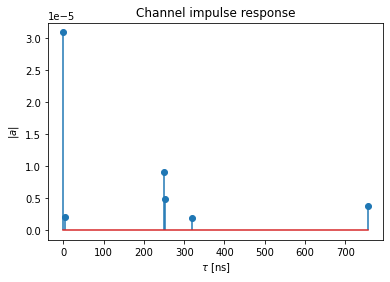

In [9]:
# CIR: channel impulse response

t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");